# Análisis exploratorio de una base de datos de películas

Usa la base de datos `./data/imdb.csv`


### 1. Importar `pandas`, `matplotlib` y `numpy`

In [59]:
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import numpy as np

### 2. Leer la base de datos del archivo csv a pandas

In [30]:
df = pd.read_csv('data/imdb.csv', encoding='ISO-8859-1')


### 3. Mostrar las  primeras y últimas filas del dataframe. Hacerlo con el valor default y pasando como argumento el número entero de filas que se deseen inspeccionar.

In [31]:
df.head(10)
df.tail(6)

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
994,995,Project X,Comedy,3 high school seniors throw a birthday party t...,Nima Nourizadeh,"Thomas Mann, Oliver Cooper, Jonathan Daniel Br...",2012,88,6.7,164088,54.72,48.0
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


### 4. Continúa inspeccionando el archivo viendo todas las columnas del dataframe

In [32]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='object')

### 5. Imprime los primeros valores de la variable `Rank`

In [33]:
df['Rank'].head()

0    1
1    2
2    3
3    4
4    5
Name: Rank, dtype: int64

### 6. Demuestra que es mejor tener nombres de columnas sin espacios (notación corchetes y notación punto-variable).

In [34]:
df['BoxOffice'].head()

KeyError: 'BoxOffice'

### 7. Renombra las columnas que tengan espacios

In [35]:
df.columns = df.columns.str.replace(' ', '')

### 8. Utiliza tus nuevas columnas sin espacios :)

In [36]:
df['Runtime(Minutes)'].head()

0    121
1    124
2    117
3    108
4    123
Name: Runtime(Minutes), dtype: int64

### 9. Visualiza la info de todo tu dataframe

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               1000 non-null   int64  
 1   Title              1000 non-null   object 
 2   Genre              1000 non-null   object 
 3   Description        1000 non-null   object 
 4   Director           1000 non-null   object 
 5   Actors             1000 non-null   object 
 6   Year               1000 non-null   int64  
 7   Runtime(Minutes)   1000 non-null   int64  
 8   Rating             1000 non-null   float64
 9   Votes              1000 non-null   int64  
 10  Revenue(Millions)  872 non-null    float64
 11  Metascore          936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


### 10. Inspecciona si hay columnas que tengan valores `NA`

In [38]:
df.isnull().sum()

Rank                   0
Title                  0
Genre                  0
Description            0
Director               0
Actors                 0
Year                   0
Runtime(Minutes)       0
Rating                 0
Votes                  0
Revenue(Millions)    128
Metascore             64
dtype: int64

### 11. Imprime el número total de valores NA que haya en cada columna. Hazlo primero para la columna `Metascore` y después utiliza un ciclo for para hacerlo para todas las columnas

In [39]:
print(df['Metascore'].isnull().sum())
for columna in df.columns:
    print(f"{columna}: {df[columna].isnull().sum()}")

64
Rank: 0
Title: 0
Genre: 0
Description: 0
Director: 0
Actors: 0
Year: 0
Runtime(Minutes): 0
Rating: 0
Votes: 0
Revenue(Millions): 128
Metascore: 64


### 12. Usa la magia de `dropna()`

In [40]:
df_sin_na = df.dropna()


### 13. Vuelve a ver la info del dataset

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               1000 non-null   int64  
 1   Title              1000 non-null   object 
 2   Genre              1000 non-null   object 
 3   Description        1000 non-null   object 
 4   Director           1000 non-null   object 
 5   Actors             1000 non-null   object 
 6   Year               1000 non-null   int64  
 7   Runtime(Minutes)   1000 non-null   int64  
 8   Rating             1000 non-null   float64
 9   Votes              1000 non-null   int64  
 10  Revenue(Millions)  872 non-null    float64
 11  Metascore          936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


### 14. Genera estadísticos descriptivos con el método `describe()`

In [42]:
df.describe()

,Rank,Year,Runtime(Minutes),Rating,Votes,Revenue(Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


### 15. Crea un histograma de la variable Metascore. Utiliza 10 cubetas

<Axes: >

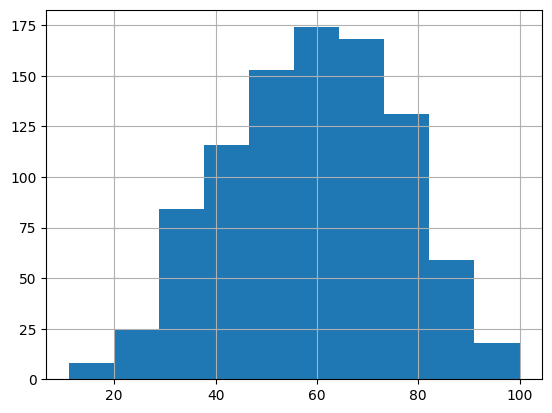

In [43]:
df['Metascore'].hist(bins=10)


### 16. Crea un histograma de la variable Rating. Utiliza 10 cubetas

<Axes: >

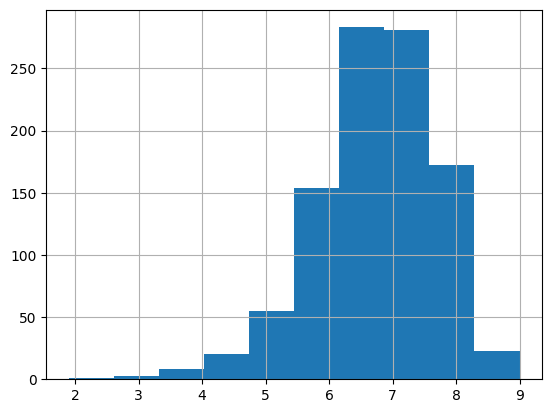

In [44]:
df['Rating'].hist(bins=10)

### 17. Vuelve a describir el dataframe y observa la media de la variable `Ratings`

In [45]:
df.describe()

,Rank,Year,Runtime(Minutes),Rating,Votes,Revenue(Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


### 18. Calcula este promedio con Numpy y después con un método de Pandas

In [50]:
promedio_numpy = np.mean(df['Rating'])
print(f"Promedio con Numpy: {promedio_numpy}")

Promedio con Numpy: 6.723199999999999


In [49]:
promedio_pandas = df['Rating'].mean()
print(f"Promedio con Pandas: {promedio_pandas}")

Promedio con Pandas: 6.723199999999999


### 19. Obten los valores únicos de la variable Rating y después ordénalos de menor a mayor

In [52]:
df['Rating'].unique()
valores_ordenados = np.sort(df['Rating'].unique())
print(valores_ordenados)

[1.9 2.7 3.2 3.5 3.7 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5.  5.1
 5.2 5.3 5.4 5.5 5.6 5.7 5.8 5.9 6.  6.1 6.2 6.3 6.4 6.5 6.6 6.7 6.8 6.9
 7.  7.1 7.2 7.3 7.4 7.5 7.6 7.7 7.8 7.9 8.  8.1 8.2 8.3 8.4 8.5 8.6 8.8
 9. ]


### 20. Observa los ratings que te interesen y ahora filtra el dataframe con ese rating para ver cuáles son las películas con dicho rating

In [53]:
peliculas_rating_9 = df[df['Rating'] == 9.0]
print(peliculas_rating_9)

    Rank            Title               Genre  \
54    55  The Dark Knight  Action,Crime,Drama   

                                          Description           Director  \
54  When the menace known as the Joker wreaks havo...  Christopher Nolan   

                                               Actors  Year  Runtime(Minutes)  \
54  Christian Bale, Heath Ledger, Aaron Eckhart,Mi...  2008               152   

    Rating    Votes  Revenue(Millions)  Metascore  
54     9.0  1791916             533.32       82.0  


### 21. Obten los valores únicos de la variable Rating y la frecuencia total de cada uno de estos valores. Posteriormente crea un nuevo dataframe con essos valores

In [55]:
df_ratings = df['Rating'].value_counts().reset_index()
df_ratings.columns = ['Rating', 'Frecuencia']
print(df_ratings)

    Rating  Frecuencia
0      7.1          52
1      6.7          48
2      7.0          46
3      6.3          44
4      7.3          42
5      7.2          42
6      6.6          42
7      6.5          40
8      7.8          40
9      6.2          37
10     6.8          37
11     7.5          35
12     6.4          35
13     7.4          33
14     6.1          31
15     6.9          31
16     7.6          27
17     7.7          27
18     5.8          26
19     6.0          26
20     8.1          26
21     7.9          23
22     5.7          21
23     5.9          19
24     8.0          19
25     5.6          17
26     5.5          14
27     5.4          12
28     5.3          12
29     5.2          11
30     8.2          10
31     4.9           7
32     8.3           7
33     8.5           6
34     4.7           6
35     4.6           5
36     5.1           5
37     4.3           4
38     5.0           4
39     8.4           4
40     4.8           4
41     3.9           3
42     8.6 

### 22. Ordena el nuevo dataframe por la variable `rating`

In [57]:
df_ratings = df_ratings.sort_values('Rating')
print(df_ratings)

    Rating  Frecuencia
53     1.9           1
45     2.7           2
51     3.2           1
44     3.5           2
47     3.7           2
41     3.9           3
50     4.0           1
48     4.1           1
43     4.2           2
37     4.3           4
54     4.4           1
52     4.5           1
35     4.6           5
34     4.7           6
40     4.8           4
31     4.9           7
38     5.0           4
36     5.1           5
29     5.2          11
28     5.3          12
27     5.4          12
26     5.5          14
25     5.6          17
22     5.7          21
18     5.8          26
23     5.9          19
19     6.0          26
14     6.1          31
9      6.2          37
3      6.3          44
12     6.4          35
7      6.5          40
6      6.6          42
1      6.7          48
10     6.8          37
15     6.9          31
2      7.0          46
0      7.1          52
5      7.2          42
4      7.3          42
13     7.4          33
11     7.5          35
16     7.6 

### 23. Crea una gráfica de barras con este nuevo dataframe ordenado

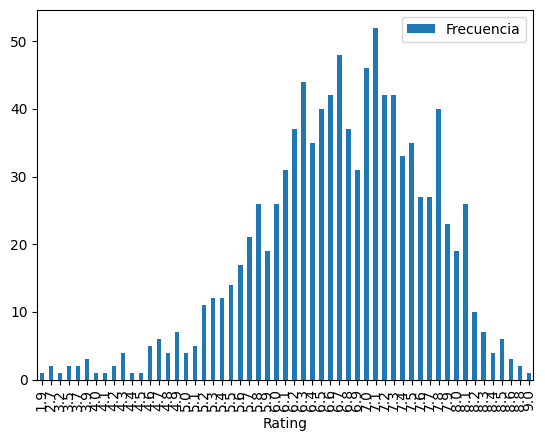

In [60]:
df_ratings.plot(x='Rating', y='Frecuencia', kind='bar')
plt.show()

### 24. Crea la matriz de correlación del dataframe de películas

In [62]:
matriz_correlacion = df.corr()
print(matriz_correlacion)

ValueError: could not convert string to float: 'Guardians of the Galaxy'

### 25. Grafica la matriz de correlación utilizando `matshow()`

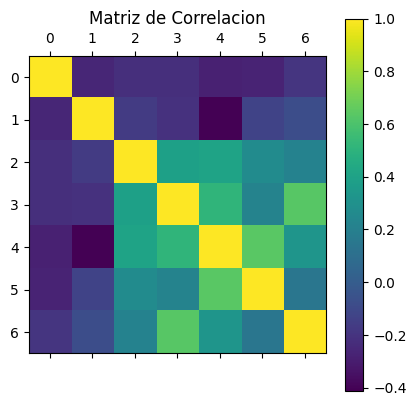

In [63]:
matriz_correlacion = df.corr(numeric_only=True)

plt.matshow(matriz_correlacion)
plt.colorbar()
plt.title('Matriz de Correlacion')
plt.show()